# Lempel-Ziv complexity and brain entropy from ROI time series

This notebook reproduces the subject-level LZC and BEN/Sample Entropy analysis from paired `.mat` ROI time-series files. The `.mat` files are restricted/private and are not included in the public repository.


## Compute subject-level metrics from private MAT files


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import detrend
from scipy.stats import shapiro, ttest_rel, wilcoxon, rankdata

# ============================================================
# CONFIGURAÇÃO (AJUSTE AQUI)
# ============================================================
PROJECT_DIR = Path.cwd()
CANDIDATE_BASE_DIRS = [
    PROJECT_DIR / "data_private" / "Aya_temporal_series",
    PROJECT_DIR / "public_repository" / "data_private" / "Aya_temporal_series",
    PROJECT_DIR / "Aya_temporal_series",
    PROJECT_DIR.parent / "Aya_temporal_series",
]
BASE_DIR = str(next((path for path in CANDIDATE_BASE_DIRS if path.exists()), CANDIDATE_BASE_DIRS[0]))
RESULTS_DIR = os.path.join(str(PROJECT_DIR), "results", "lzc_ben")
os.makedirs(RESULTS_DIR, exist_ok=True)
COND_BEFORE = "before"
COND_AFTER = "after"

# BEN / Sample Entropy parameters (padrão comum para séries curtas)
SAMPEN_M = 2
SAMPEN_R_FRAC = 0.2  # r = 0.2 * std(x)

ALPHA_NORMALITY = 0.05  # Shapiro


# ============================================================
# LEITURA ROBUSTA DE .MAT (1 série temporal por arquivo)
# ============================================================
def load_timeseries_from_mat(mat_path: str) -> np.ndarray:
    """
    Extrai uma série temporal 1D (T,) de um arquivo .mat.
    Estratégia:
      - ignora chaves '__*'
      - se existir alguma variável que comece com 'X_', usa essa
      - senão, usa o maior array numérico disponível
    """
    d = loadmat(mat_path)
    keys = [k for k in d.keys() if not k.startswith("__")]
    if len(keys) == 0:
        raise ValueError(f"Nenhuma variável útil em: {mat_path}")

    # preferir X_*
    for k in keys:
        if k.startswith("X_"):
            x = np.asarray(d[k]).squeeze().astype(float)
            if x.ndim == 1:
                return x

    # fallback: maior array numérico que vire 1D
    best = None
    best_len = -1
    for k in keys:
        arr = np.asarray(d[k])
        if not np.issubdtype(arr.dtype, np.number):
            continue
        x = arr.squeeze().astype(float)
        if x.ndim == 1 and x.size > best_len:
            best = x
            best_len = x.size

    if best is None:
        raise ValueError(f"Não encontrei série 1D numérica em: {mat_path}")

    return best


def preprocess(x: np.ndarray) -> np.ndarray:
    """detrend + z-score (recomendado antes de LZC/SampEn)."""
    x = detrend(x, type="linear")
    sd = np.std(x)
    if sd == 0 or np.isnan(sd):
        return np.zeros_like(x)
    x = (x - np.mean(x)) / sd
    return x


# ============================================================
# LZC (Lempel–Ziv) para sequência binária (normalizada)
# ============================================================
def lz_complexity_binary(seq01: np.ndarray) -> int:
    s = ''.join(seq01.astype(int).astype(str))
    n = len(s)

    i, k, l = 0, 1, 1
    c = 1
    k_max = 1

    while True:
        if i + k > n or l + k > n:
            c += 1
            break

        if s[i + k - 1] == s[l + k - 1]:
            k += 1
            if l + k > n:
                c += 1
                break
        else:
            if k > k_max:
                k_max = k
            i += 1
            if i == l:
                c += 1
                l += k_max
                if l >= n:
                    break
                i = 0
                k = 1
                k_max = 1
            else:
                k = 1
    return c


def lzc_normalized(x: np.ndarray) -> float:
    x = preprocess(x)
    med = np.median(x)
    b = (x > med).astype(int)
    n = len(b)
    if n < 2:
        return np.nan
    c = lz_complexity_binary(b)
    norm = n / np.log2(n) if n > 1 else np.nan
    return float(c / norm)


# ============================================================
# Sample Entropy (BEN via SampEn) - implementação direta
# ============================================================
def sample_entropy(x: np.ndarray, m: int = 2, r_frac: float = 0.2) -> float:
    x = preprocess(x)
    n = len(x)
    if n <= m + 1:
        return np.nan

    r = r_frac * np.std(x)
    if r == 0 or np.isnan(r):
        return 0.0

    def embed(sig, dim):
        return np.array([sig[i:i + dim] for i in range(n - dim + 1)])

    Xm = embed(x, m)       # (n-m+1, m)
    Xm1 = embed(x, m + 1)  # (n-m,   m+1)

    def count_matches(X):
        count = 0
        N = len(X)
        for i in range(N):
            d = np.max(np.abs(X - X[i]), axis=1)  # Chebyshev
            count += (np.sum(d <= r) - 1)         # remove auto-match
        return count

    B = count_matches(Xm)
    A = count_matches(Xm1)

    if B <= 0 or A <= 0:
        return np.nan

    return float(-np.log(A / B))


# ============================================================
# Estatística: Shapiro + decisão do teste pareado
# ============================================================
def rank_biserial_paired(before, after) -> float:
    d = np.array(after) - np.array(before)
    d = d[d != 0]
    n = len(d)
    if n == 0:
        return np.nan
    ranks = rankdata(np.abs(d))
    W_pos = np.sum(ranks[d > 0])
    W_neg = np.sum(ranks[d < 0])
    denom = n * (n + 1) / 2
    return float((W_pos - W_neg) / denom)


def run_paired_test(before, after, alpha=0.05):
    before = np.array(before, dtype=float)
    after = np.array(after, dtype=float)
    diff = after - before

    # Shapiro solicitado (before, after e diferenças)
    p_b = shapiro(before).pvalue
    p_a = shapiro(after).pvalue
    p_d = shapiro(diff).pvalue

    assumed_normal = (p_b > alpha) and (p_a > alpha) and (p_d > alpha)

    out = {
        "shapiro_before_p": float(p_b),
        "shapiro_after_p": float(p_a),
        "shapiro_diff_p": float(p_d),
        "assumed_normal": bool(assumed_normal)
    }

    if assumed_normal:
        t = ttest_rel(after, before, nan_policy="omit")
        sd = np.std(diff, ddof=1)
        dz = float(np.mean(diff) / sd) if sd > 0 else np.nan
        out.update({
            "test": "paired t-test",
            "stat": float(t.statistic),
            "pvalue": float(t.pvalue),
            "effect_size_name": "Cohen's dz",
            "effect_size": float(dz)
        })
    else:
        w = wilcoxon(after, before, zero_method="wilcox", correction=False, alternative="two-sided")
        rrb = rank_biserial_paired(before, after)
        out.update({
            "test": "Wilcoxon signed-rank",
            "stat": float(w.statistic),
            "pvalue": float(w.pvalue),
            "effect_size_name": "rank-biserial correlation",
            "effect_size": float(rrb)
        })

    return out


# ============================================================
# PIPELINE PRINCIPAL
# ============================================================
def list_subject_folders(cond_path: str):
    subs = []
    for name in os.listdir(cond_path):
        p = os.path.join(cond_path, name)
        if os.path.isdir(p) and not name.startswith("."):
            subs.append(name)
    return sorted(subs)


def list_mat_files(subj_path: str):
    files = [f for f in os.listdir(subj_path) if f.lower().endswith(".mat")]
    files.sort()
    return files


def compute_subject_metrics(subj_path: str):
    mats = list_mat_files(subj_path)
    if len(mats) == 0:
        raise RuntimeError(f"Nenhum .mat em {subj_path}")

    lzc_vals = []
    ben_vals = []

    for f in mats:
        fp = os.path.join(subj_path, f)
        x = load_timeseries_from_mat(fp)

        lzc_vals.append(lzc_normalized(x))
        ben_vals.append(sample_entropy(x, m=SAMPEN_M, r_frac=SAMPEN_R_FRAC))

    lzc_vals = np.array(lzc_vals, dtype=float)
    ben_vals = np.array(ben_vals, dtype=float)

    return {
        "n_rois": int(len(mats)),
        "lzc_median": float(np.nanmedian(lzc_vals)),
        "lzc_mean": float(np.nanmean(lzc_vals)),
        "ben_median": float(np.nanmedian(ben_vals)),
        "ben_mean": float(np.nanmean(ben_vals)),
    }


def main():
    before_path = os.path.join(BASE_DIR, COND_BEFORE)
    after_path = os.path.join(BASE_DIR, COND_AFTER)

    if not os.path.isdir(before_path) or not os.path.isdir(after_path):
        raise FileNotFoundError("Confira BASE_DIR e as pastas before/after.")

    subs_before = set(list_subject_folders(before_path))
    subs_after = set(list_subject_folders(after_path))
    subjects = sorted(list(subs_before.intersection(subs_after)))

    if len(subjects) == 0:
        raise RuntimeError("Não encontrei pastas de sujeitos comuns em before e after.")

    rows = []
    for subj in subjects:
        b_dir = os.path.join(before_path, subj)
        a_dir = os.path.join(after_path, subj)

        mb = compute_subject_metrics(b_dir)
        ma = compute_subject_metrics(a_dir)

        rows.append({
            "subject": subj,
            "n_rois_before": mb["n_rois"],
            "n_rois_after": ma["n_rois"],

            "LZC_before_median": mb["lzc_median"],
            "LZC_after_median":  ma["lzc_median"],
            "LZC_delta_median":  ma["lzc_median"] - mb["lzc_median"],

            "BEN_before_median": mb["ben_median"],
            "BEN_after_median":  ma["ben_median"],
            "BEN_delta_median":  ma["ben_median"] - mb["ben_median"],

            "LZC_before_mean": mb["lzc_mean"],
            "LZC_after_mean":  ma["lzc_mean"],
            "LZC_delta_mean":  ma["lzc_mean"] - mb["lzc_mean"],

            "BEN_before_mean": mb["ben_mean"],
            "BEN_after_mean":  ma["ben_mean"],
            "BEN_delta_mean":  ma["ben_mean"] - mb["ben_mean"],
        })

        print(f"[OK] {subj} | ROIs before={mb['n_rois']} after={ma['n_rois']}")

    df = pd.DataFrame(rows)

    out_csv = os.path.join(RESULTS_DIR, "LZC_BEN_subject_summary.csv")
    df.to_csv(out_csv, index=False)

    # ===== Teste pareado no nível do grupo (n=9) =====
    stats = {}
    stats["LZC_median"] = run_paired_test(df["LZC_before_median"], df["LZC_after_median"], alpha=ALPHA_NORMALITY)
    stats["BEN_median"] = run_paired_test(df["BEN_before_median"], df["BEN_after_median"], alpha=ALPHA_NORMALITY)

    # Sensibilidade (média das ROIs)
    stats["LZC_mean"] = run_paired_test(df["LZC_before_mean"], df["LZC_after_mean"], alpha=ALPHA_NORMALITY)
    stats["BEN_mean"] = run_paired_test(df["BEN_before_mean"], df["BEN_after_mean"], alpha=ALPHA_NORMALITY)

    # ===== Resumo em TXT =====
    out_txt = os.path.join(RESULTS_DIR, "LZC_BEN_stats_report.txt")
    with open(out_txt, "w", encoding="utf-8") as f:
        f.write("=== LZC / BEN (Sample Entropy) - Before vs After (pareado) ===\n\n")
        f.write(f"Base dir: {BASE_DIR}\n")
        f.write(f"N subjects: {len(df)}\n\n")

        f.write("---- Subject-level table (first rows) ----\n")
        f.write(df.head(20).to_string(index=False))
        f.write("\n\n")

        def write_block(name, r):
            f.write(f"== {name} ==\n")
            f.write(f"Shapiro p(before) = {r['shapiro_before_p']:.6f}\n")
            f.write(f"Shapiro p(after)  = {r['shapiro_after_p']:.6f}\n")
            f.write(f"Shapiro p(diff)   = {r['shapiro_diff_p']:.6f}\n")
            f.write(f"Assumed normal?   = {r['assumed_normal']}\n")
            f.write(f"Test              = {r['test']}\n")
            f.write(f"Statistic         = {r['stat']:.6f}\n")
            f.write(f"p-value           = {r['pvalue']:.8f}\n")
            f.write(f"Effect size       = {r['effect_size_name']}: {r['effect_size']:.6f}\n\n")

        write_block("LZC (median over ROIs)", stats["LZC_median"])
        write_block("BEN/SampEn (median over ROIs)", stats["BEN_median"])
        write_block("LZC (mean over ROIs)", stats["LZC_mean"])
        write_block("BEN/SampEn (mean over ROIs)", stats["BEN_mean"])

    print("\nArquivos gerados:")
    print(f"  - {out_csv}")
    print(f"  - {out_txt}")
    print("\nResumo rápido (mediana por sujeito):")
    for k in ["LZC_median", "BEN_median"]:
        r = stats[k]
        print(f"\n{k}: {r['test']}, p={r['pvalue']:.6g}, efeito={r['effect_size_name']}={r['effect_size']:.3f}")


if __name__ == "__main__":
    main()


[OK] s_1_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_2_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_3_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_4_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_5_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_6_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_7_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_8_serie_temporal_filtrada | ROIs before=104 after=104
[OK] s_9_serie_temporal_filtrada | ROIs before=104 after=104

Arquivos gerados:
  - D:\OneDrive\Coding\article_repository\public_repository\results\lzc_ben\LZC_BEN_subject_summary.csv
  - D:\OneDrive\Coding\article_repository\public_repository\results\lzc_ben\LZC_BEN_stats_report.txt

Resumo rápido (mediana por sujeito):

LZC_median: Wilcoxon signed-rank, p=0.4375, efeito=rank-biserial correlation=0.429

BEN_median: paired t-test, p=0.205354, efeito=Cohen's dz=0.460


## Load generated summary table


In [2]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path.cwd()
CANDIDATE_SUMMARY_FILES = [
    PROJECT_DIR / "results" / "lzc_ben" / "LZC_BEN_subject_summary.csv",
    PROJECT_DIR / "public_repository" / "results" / "lzc_ben" / "LZC_BEN_subject_summary.csv",
    PROJECT_DIR / "Aya_temporal_series" / "LZC_BEN_subject_summary.csv",
    PROJECT_DIR.parent / "Aya_temporal_series" / "LZC_BEN_subject_summary.csv",
]
csv_path = next((path for path in CANDIDATE_SUMMARY_FILES if path.exists()), CANDIDATE_SUMMARY_FILES[0])

# Local fallback for the preparation workspace only. In the public repository,
# rerun the previous cell after placing private .mat files under data_private\Aya_temporal_series.
if not csv_path.exists():
    raise FileNotFoundError(
        "LZC_BEN_subject_summary.csv was not found. Run the previous cell first, "
        "or set csv_path to a private precomputed summary file."
    )

df = pd.read_csv(csv_path)
df.head()


,subject,n_rois_before,n_rois_after,LZC_before_median,LZC_after_median,LZC_delta_median,BEN_before_median,BEN_after_median,BEN_delta_median,LZC_before_mean,LZC_after_mean,LZC_delta_mean,BEN_before_mean,BEN_after_mean,BEN_delta_mean
0,s_1_serie_temporal_filtrada,104,104,0.674690,0.674690,0.000000,0.844601,0.871056,0.026455,0.662642,0.669129,0.006487,0.847496,0.885256,0.037760
1,s_2_serie_temporal_filtrada,104,104,0.674690,0.722882,0.048192,0.868631,0.883446,0.014815,0.688128,0.719175,0.031047,0.871825,0.891295,0.019469
2,s_3_serie_temporal_filtrada,104,104,0.626498,0.722882,0.096384,0.823835,0.873237,0.049402,0.651057,0.709907,0.058850,0.825171,0.885610,0.060438
3,s_4_serie_temporal_filtrada,104,104,0.722882,0.722882,0.000000,0.872660,0.906470,0.033811,0.689981,0.724735,0.034754,0.871890,0.897985,0.026094
4,s_5_serie_temporal_filtrada,104,104,0.722882,0.722882,0.000000,0.874190,0.889620,0.015431,0.684421,0.705737,0.021316,0.868555,0.894722,0.026167


## Paired tests and plots


=== LZC (median over ROIs, subject-level) ===
Shapiro on diffs p = 0.5896 | assume normal diffs? True
Test: paired t-test | stat=1.257 | p=0.244129
Effect: Cohen's dz = 0.4191
Paired change (mean diff)   = 0.01874 | boot 95% CI mean   = (-0.008032020767217676, 0.04819212460330581)
Paired change (median diff) = 0 | boot 95% CI median = (-0.024096062301652954, 0.0481921246033058)
Interpretation: No statistically significant paired change detected (p=0.2441). Bootstrap 95% CI for the paired change (mean) = [-0.008032, 0.04819] (includes 0).


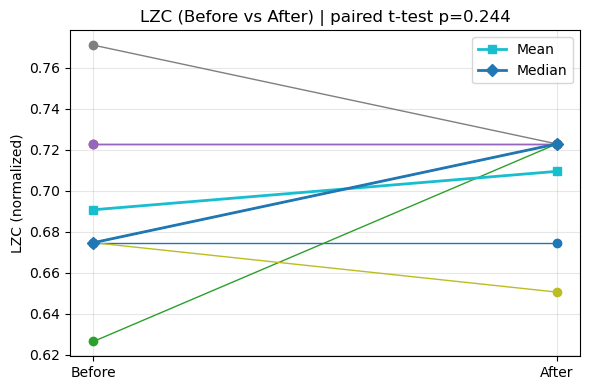


=== BEN (Sample Entropy; median over ROIs, subject-level) ===
Shapiro on diffs p = 0.1371 | assume normal diffs? True
Test: paired t-test | stat=1.379 | p=0.205354
Effect: Cohen's dz = 0.4595
Paired change (mean diff)   = 0.0151 | boot 95% CI mean   = (-0.006760874354324134, 0.033318147451571016)
Paired change (median diff) = 0.02375 | boot 95% CI median = (-0.022301442371620572, 0.046611863818167176)
Interpretation: No statistically significant paired change detected (p=0.2054). Bootstrap 95% CI for the paired change (mean) = [-0.006761, 0.03332] (includes 0).


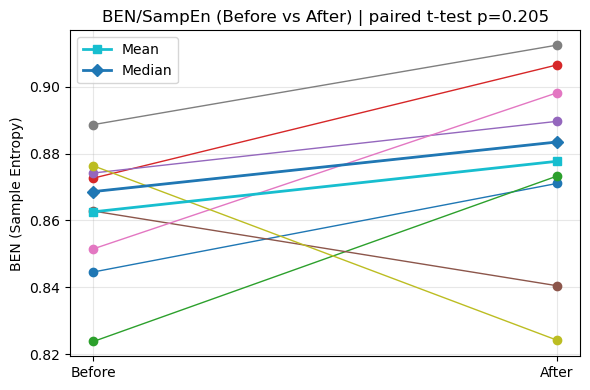

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_rel, wilcoxon, rankdata

def rank_biserial_paired(before, after):
    d = np.asarray(after) - np.asarray(before)
    d = d[d != 0]
    n = len(d)
    if n == 0:
        return np.nan
    ranks = rankdata(np.abs(d))
    W_pos = np.sum(ranks[d > 0])
    W_neg = np.sum(ranks[d < 0])
    denom = n * (n + 1) / 2
    return float((W_pos - W_neg) / denom)

def bootstrap_ci(diff, stat_fn=np.mean, n_boot=20000, ci=95, seed=123):
    """
    Bootstrap pareado sobre as diferenças (after - before).
    Retorna IC percentual [lo, hi] para estatística (média/mediana).
    """
    rng = np.random.default_rng(seed)
    diff = np.asarray(diff, dtype=float)
    diff = diff[~np.isnan(diff)]
    n = len(diff)
    if n == 0:
        return (np.nan, np.nan)
    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        sample = rng.choice(diff, size=n, replace=True)
        boots[b] = stat_fn(sample)
    alpha = (100 - ci) / 2
    lo = np.percentile(boots, alpha)
    hi = np.percentile(boots, 100 - alpha)
    return float(lo), float(hi)

def paired_test_and_interpret(before, after, alpha=0.05):
    """
    Decide t pareado vs Wilcoxon baseado em Shapiro nas diferenças.
    Retorna dict com resultados + interpretações rápidas.
    """
    before = np.asarray(before, dtype=float)
    after  = np.asarray(after, dtype=float)
    diff = after - before
    
    # Normalidade (diferenças) — suposição do t-teste pareado
    p_sh = shapiro(diff).pvalue
    normal = (p_sh > alpha)
    
    out = {"shapiro_diff_p": float(p_sh), "assumed_normal_diff": bool(normal)}
    
    if normal:
        res = ttest_rel(after, before, nan_policy="omit")
        sd = np.std(diff, ddof=1)
        dz = float(np.mean(diff) / sd) if sd > 0 else np.nan
        out.update({
            "test": "paired t-test",
            "stat": float(res.statistic),
            "pvalue": float(res.pvalue),
            "effect_name": "Cohen's dz",
            "effect": float(dz),
        })
    else:
        res = wilcoxon(after, before, zero_method="wilcox", correction=False, alternative="two-sided")
        rrb = rank_biserial_paired(before, after)
        out.update({
            "test": "Wilcoxon signed-rank",
            "stat": float(res.statistic),
            "pvalue": float(res.pvalue),
            "effect_name": "rank-biserial correlation",
            "effect": float(rrb),
        })
    
    # Bootstrap CIs (média e mediana das diferenças)
    out["boot_ci_mean"] = bootstrap_ci(diff, stat_fn=np.mean)
    out["boot_ci_median"] = bootstrap_ci(diff, stat_fn=np.median)
    out["diff_mean"] = float(np.mean(diff))
    out["diff_median"] = float(np.median(diff))
    out["significant"] = bool(out["pvalue"] < alpha)
    
    # Interpretação curta baseada em p e CI
    ci_lo, ci_hi = out["boot_ci_mean"] if normal else out["boot_ci_median"]
    center = out["diff_mean"] if normal else out["diff_median"]
    ci_crosses_zero = (ci_lo <= 0 <= ci_hi)
    out["ci_crosses_zero"] = bool(ci_crosses_zero)
    
    if out["significant"]:
        direction = "increase" if center > 0 else "decrease" if center < 0 else "no change"
        out["interpretation"] = (
            f"Evidence of a {direction} from before to after (p={out['pvalue']:.4g}). "
            f"Bootstrap 95% CI for the paired change "
            f"({'mean' if normal else 'median'}) = [{ci_lo:.4g}, {ci_hi:.4g}]."
        )
    else:
        out["interpretation"] = (
            f"No statistically significant paired change detected (p={out['pvalue']:.4g}). "
            f"Bootstrap 95% CI for the paired change "
            f"({'mean' if normal else 'median'}) = [{ci_lo:.4g}, {ci_hi:.4g}] "
            f"({'includes' if ci_crosses_zero else 'does not include'} 0)."
        )
    return out

def plot_paired(before, after, title, ylabel):
    """
    Gráfico pareado: linhas por sujeito + marcadores de média e mediana.
    """
    before = np.asarray(before, dtype=float)
    after  = np.asarray(after, dtype=float)
    n = len(before)
    
    x = np.array([0, 1])
    plt.figure(figsize=(6, 4))
    
    # Linhas por sujeito
    for i in range(n):
        plt.plot(x, [before[i], after[i]], marker='o', linewidth=1)
    
    # Estatísticas agregadas
    mean_vals = [np.mean(before), np.mean(after)]
    med_vals  = [np.median(before), np.median(after)]
    plt.plot(x, mean_vals, marker='s', linewidth=2, label='Mean')
    plt.plot(x, med_vals,  marker='D', linewidth=2, label='Median')
    
    plt.xticks([0, 1], ['Before', 'After'])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================
# EXECUÇÃO (ajuste nomes se necessário)
# =========================

# LZC (mediana por sujeito agregando ROIs)
lzc_before = df["LZC_before_median"].values
lzc_after  = df["LZC_after_median"].values
res_lzc = paired_test_and_interpret(lzc_before, lzc_after, alpha=0.05)

print("=== LZC (median over ROIs, subject-level) ===")
print(f"Shapiro on diffs p = {res_lzc['shapiro_diff_p']:.4g} | assume normal diffs? {res_lzc['assumed_normal_diff']}")
print(f"Test: {res_lzc['test']} | stat={res_lzc['stat']:.4g} | p={res_lzc['pvalue']:.6g}")
print(f"Effect: {res_lzc['effect_name']} = {res_lzc['effect']:.4g}")
print(f"Paired change (mean diff)   = {res_lzc['diff_mean']:.4g} | boot 95% CI mean   = {res_lzc['boot_ci_mean']}")
print(f"Paired change (median diff) = {res_lzc['diff_median']:.4g} | boot 95% CI median = {res_lzc['boot_ci_median']}")
print("Interpretation:", res_lzc["interpretation"])
plot_paired(lzc_before, lzc_after, 
            title=f"LZC (Before vs After) | {res_lzc['test']} p={res_lzc['pvalue']:.3g}",
            ylabel="LZC (normalized)")

# BEN / Sample Entropy (mediana por sujeito agregando ROIs)
ben_before = df["BEN_before_median"].values
ben_after  = df["BEN_after_median"].values
res_ben = paired_test_and_interpret(ben_before, ben_after, alpha=0.05)

print("\n=== BEN (Sample Entropy; median over ROIs, subject-level) ===")
print(f"Shapiro on diffs p = {res_ben['shapiro_diff_p']:.4g} | assume normal diffs? {res_ben['assumed_normal_diff']}")
print(f"Test: {res_ben['test']} | stat={res_ben['stat']:.4g} | p={res_ben['pvalue']:.6g}")
print(f"Effect: {res_ben['effect_name']} = {res_ben['effect']:.4g}")
print(f"Paired change (mean diff)   = {res_ben['diff_mean']:.4g} | boot 95% CI mean   = {res_ben['boot_ci_mean']}")
print(f"Paired change (median diff) = {res_ben['diff_median']:.4g} | boot 95% CI median = {res_ben['boot_ci_median']}")
print("Interpretation:", res_ben["interpretation"])
plot_paired(ben_before, ben_after, 
            title=f"BEN/SampEn (Before vs After) | {res_ben['test']} p={res_ben['pvalue']:.3g}",
            ylabel="BEN (Sample Entropy)")


In [4]:
print(df)


                       subject  n_rois_before  n_rois_after  \
0  s_1_serie_temporal_filtrada            104           104   
1  s_2_serie_temporal_filtrada            104           104   
2  s_3_serie_temporal_filtrada            104           104   
3  s_4_serie_temporal_filtrada            104           104   
4  s_5_serie_temporal_filtrada            104           104   
5  s_6_serie_temporal_filtrada            104           104   
6  s_7_serie_temporal_filtrada            104           104   
7  s_8_serie_temporal_filtrada            104           104   
8  s_9_serie_temporal_filtrada            104           104   

   LZC_before_median  LZC_after_median  LZC_delta_median  BEN_before_median  \
0           0.674690          0.674690          0.000000           0.844601   
1           0.674690          0.722882          0.048192           0.868631   
2           0.626498          0.722882          0.096384           0.823835   
3           0.722882          0.722882          0.000